In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, Model, ops
from keras.optimizers import Adam, Adadelta
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import numpy.typing as npt
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import gensim
# Necesario para TextVectorization y tf.data
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Literal


In [2]:
print(keras.config.backend())


torch


In [3]:
BASE_DIR = Path.cwd().parents[0]

DATA_PATH = BASE_DIR / "data"
PROCESSED_DATA_PATH = DATA_PATH / "processed"

WORD2VEC_PATH = "../models/spanish_word2vec/spanish_word2vec.wordvectors"

def load_sts(split: str, path: Path):
	return pd.read_csv(
		path / f"stsb-es-{split}.csv",
	)


In [4]:
MAX_LEN = 25
EMBED_DIM = 400
HIDDEN_DIM = 50
BATCH_SIZE = 64
EPOCHS = 20


In [5]:
splits = ["train", "dev", "test"]

datasets = {
	split: load_sts(split, PROCESSED_DATA_PATH)
	for split in splits
}

train_df = datasets["train"]
dev_df = datasets["dev"]
test_df = datasets["test"]

In [6]:
all_sentences = list(train_df['sentence1']) + list(train_df['sentence2'])

vectorizer = layers.TextVectorization(
	max_tokens=None,
	output_mode='int',
	output_sequence_length=MAX_LEN,
)

vectorizer.adapt(all_sentences)

vocab = vectorizer.get_vocabulary()
word2idx = {word: idx for idx, word in enumerate(vocab)}
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 13713


In [7]:
def load_gensim_embeddings(path, word2idx: dict, embed_dim: int):
	wv = gensim.models.KeyedVectors.load(path, mmap='r')
	embedding_matrix = np.random.uniform(-0.05, 0.05, (len(word2idx), embed_dim))
	# El índice 0 se utiliza como padding token, por lo que tiene un vector de ceros, para indicar que no contribuye
	embedding_matrix[0] = 0
	found = 0
	for word, idx in word2idx.items():
		if word in wv.key_to_index:
			embedding_matrix[idx] = wv[word]
			found += 1
	print(f"Found {found}/{len(word2idx)} words.")
	return embedding_matrix

embedding_matrix = load_gensim_embeddings(WORD2VEC_PATH, word2idx, EMBED_DIM)

Found 13305/13713 words.


In [8]:
def encode_sentences(sent1, sent2, label):
	seq1 = vectorizer(sent1)
	seq2 = vectorizer(sent2)
	return seq1, seq2, label

# def encode_sentence(sentence: str):
#     vectorized = vectorizer(np.array([sentence]))
#     return np.array(vectorized[0])

In [9]:
def create_dataset(df: pd.DataFrame, batch_size: int, shuffle: bool=False):
	sent1 = tf.constant(df['sentence1'].values, dtype=tf.string)
	sent2 = tf.constant(df['sentence2'].values, dtype=tf.string)
	labels = tf.constant(df['label'].values, dtype=tf.float32)
	dataset = tf.data.Dataset.from_tensor_slices((sent1, sent2, labels))
	
	dataset = dataset.map(encode_sentences, num_parallel_calls=tf.data.AUTOTUNE)

	dataset = dataset.map(
		lambda sent1, sent2, labels: ((sent1, sent2), labels),
		num_parallel_calls=tf.data.AUTOTUNE
	)

	if shuffle:
		dataset = dataset.shuffle(len(df))

	dataset = dataset.batch(batch_size)
	dataset = dataset.prefetch(tf.data.AUTOTUNE)
	
	return dataset

# def create_dataset(df, encode_fn, shuffle: bool = False):
#     sent1 = np.array([encode_fn(sent) for sent in df['sentence1'].values])
#     sent2 = np.array([encode_fn(sent) for sent in df['sentence2'].values])
#     labels = df['label'].values.astype(np.float32)
	
#     if shuffle:
#         idx = np.arange(len(labels))
#         np.random.shuffle(idx)
#         sent1 = sent1[idx]
#         sent2 = sent2[idx]
#         labels = labels[idx]

#     return (sent1, sent2), labels

In [10]:
train_dataset = create_dataset(train_df, BATCH_SIZE, shuffle=False)
dev_dataset = create_dataset(dev_df, BATCH_SIZE)
test_dataset = create_dataset(test_df, BATCH_SIZE)

# train_dataset = create_dataset(train_df, encode_sentence, shuffle=False)
# dev_dataset = create_dataset(dev_df, encode_sentence)
# test_dataset = create_dataset(test_df, encode_sentence)


In [11]:
def l2_normalize(x, axis=1):
	norm = ops.sqrt(ops.sum(ops.square(x), axis=axis, keepdims=True))
	return x / (norm + 1e-8)

def cosine_similarity(x, y):
	x_norm = l2_normalize(x)
	y_norm = l2_normalize(y)
	return ops.sum(x_norm * y_norm, axis=1, keepdims=True)

def manhattan_similarity(x, y):
	distance = ops.sum(ops.abs(x - y), axis=1, keepdims=True)
	return ops.exp(-distance)

In [12]:
class SiameseLSTM(Model):
	def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int, embedding_matrix: npt.NDArray, pooling: Literal["last", "mean"], similarity: Literal["manhattan", "cosine"], dropout: float = 0.2, name="siamese_lstm", **kwargs):
		super().__init__(name=name, **kwargs)

		self.vocab_size = vocab_size
		self.embedding_dim = embedding_dim
		self.hidden_dim = hidden_dim
		self.pooling = pooling
		self.similarity = similarity

		initializer = keras.initializers.Constant(embedding_matrix)
			
		self.embedding = layers.Embedding(
			input_dim=vocab_size,
			output_dim=embedding_dim,
			embeddings_initializer=initializer,
			trainable=False,
			mask_zero=True,
			name="embedding"
		)

		self.lstm = layers.LSTM(
			hidden_dim,
			return_sequences=True,
			dropout=dropout,
			recurrent_dropout=dropout,
			name="lstm"
		)

	def masked_mean_pool(self, hidden_states, mask):
		# mask (batch, seq_len)
		mask = ops.cast(mask, hidden_states.dtype)

		# Expandir máscara para que coincida con el estado oculto
		# (batch, seq_len) -> (batch, seq_len, 1)
		mask = ops.expand_dims(mask, axis=-1)

		# hidden_states (batch, seq_len, 1)
		# mask (batch, seq_len, hidden_dim)
		masked_hidden = hidden_states * mask

		sum_hidden = ops.sum(masked_hidden, axis=1)
		# Contar el número de palabras sin padding
		token_count = ops.sum(mask, axis=1)

		return sum_hidden / (token_count + 1e-8)

	def pool(self, x, mask):
		if self.pooling == "last":
			# Si hay padding, se copia el estado anterior
			return x[:, -1, :]
		elif self.pooling == "mean":
			return self.masked_mean_pool(x, mask)
	
	def compute_similarity(self, x, y):
		if self.similarity == "manhattan":
			return manhattan_similarity(x, y)
		elif self.similarity == "cosine":
			return cosine_similarity(x, y)
		
	def call(self, inputs, training=False):
		sent1, sent2 = inputs

		emb1 = self.embedding(sent1)
		emb2 = self.embedding(sent2)

		mask1 = self.embedding.compute_mask(sent1)
		mask2 = self.embedding.compute_mask(sent2)

		lstm_out1 = self.lstm(emb1, training=training)
		lstm_out2 = self.lstm(emb2, training=training)	

		vec1 = self.pool(lstm_out1, mask1)
		vec2 = self.pool(lstm_out2, mask2)
	
		similarity = self.compute_similarity(vec1, vec2)
		
		return similarity
	
	def get_config(self):
		config = super().get_config()
		config.update({
			"vocab_size": self.vocab_size,
			"embedding_dim": self.embedding_dim,
			"hidden_dim": self.hidden_dim,
		})
		return config
	
	def get_head_model(self):
		input_sent = layers.Input(shape=(None,), dtype=tf.int32, name="input_sentence")
		emb = self.embedding(input_sent)
		mask = self.embedding.compute_mask(input_sent)
		lstm_out = self.lstm(emb, training=False)
		vec = self.pool(lstm_out, mask)
		return Model(inputs=input_sent, outputs=vec, name="siamese_head")
	

In [13]:
model = SiameseLSTM(len(vocab), EMBED_DIM, HIDDEN_DIM, embedding_matrix, "mean", "cosine")


In [14]:
head_model = model.get_head_model()
head_model.summary()


Model: "siamese_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sentence      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ input_sentence[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 400) │  5,485,200 │ input_sentence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, None)      │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, None, 50)  │     90,200 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, None, 1)   │          0 │ cast[0][0]        │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, None, 50)  │          0 │ lstm[0][0],       │
│                     │                   │            │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_1 (Sum)         │ (None, 1)         │          0 │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (Sum)           │ (None, 50)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ sum_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 50)        │          0 │ sum[0][0],        │
│ (TrueDivide)        │                   │            │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,575,400 (21.27 MB)

 Trainable params: 90,200 (352.34 KB)

 Non-trainable params: 5,485,200 (20.92 MB)

In [15]:
dummy_sent1 = tf.zeros((1, MAX_LEN), dtype=tf.int32)
dummy_sent2 = tf.zeros((1, MAX_LEN), dtype=tf.int32)

model((dummy_sent1, dummy_sent2))

model.summary()

Model: "siamese_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 400)      │     5,485,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 50)       │        90,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,575,400 (21.27 MB)

 Trainable params: 90,200 (352.34 KB)

 Non-trainable params: 5,485,200 (20.92 MB)

In [16]:
# def pearson_correlation(y_true, y_pred):    
# 	# Medias
# 	mean_true = np.mean(y_true)
# 	mean_pred = np.mean(y_pred)
	
# 	# Covarianza
# 	cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
	
# 	# Desviaciones estándar
# 	std_true = np.std(y_true)
# 	std_pred = np.std(y_pred)
	
# 	# Pearson
# 	return cov / (std_true * std_pred + 1e-8)


In [17]:
# optimizer = Adadelta(learning_rate=1.0, clipnorm=1.0)
optimizer=Adam(learning_rate=1e-3, clipnorm=1.0)

# Ranngos óptimos
# MSE = 0.1-0.2
# MAE = 0.25-0.35
model.compile(
	optimizer=optimizer,
	loss='mse',
	metrics=['mae']
)

In [18]:
callbacks = [
	EarlyStopping(
		monitor="val_loss",
		patience=3,
		restore_best_weights=True,
	),
	# ModelCheckpoint(
	# 	filepath="../models/best_malstm.keras",
	# 	monitor="val_loss",
	# 	save_best_only=True,
	# ),
	ReduceLROnPlateau(
		monitor="val_loss",
		factor=0.5,
		patience=3,
		min_lr=1e-6,
	)
]


In [19]:
for (s1, s2), y in train_dataset.take(1):
	print("s1:", s1.shape)
	print("s2:", s2.shape)
	print("y:", y.shape)

s1: (64, 25)
s2: (64, 25)
y: (64,)


In [20]:
history = model.fit(
	train_dataset,
	validation_data=dev_dataset,
	epochs=EPOCHS,
	callbacks=callbacks
)


Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 547ms/step - loss: 0.0728 - mae: 0.2194 - val_loss: 0.0850 - val_mae: 0.2334 - learning_rate: 0.0010
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 503ms/step - loss: 0.0594 - mae: 0.1971 - val_loss: 0.0760 - val_mae: 0.2225 - learning_rate: 0.0010
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 516ms/step - loss: 0.0518 - mae: 0.1842 - val_loss: 0.0801 - val_mae: 0.2279 - learning_rate: 0.0010
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 541ms/step - loss: 0.0461 - mae: 0.1740 - val_loss: 0.0714 - val_mae: 0.2155 - learning_rate: 0.0010
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 545ms/step - loss: 0.0416 - mae: 0.1648 - val_loss: 0.0716 - val_mae: 0.2146 - learning_rate: 0.0010
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 50s 560ms/step - loss: 0.0376 - mae: 0.1560 - val_loss: 0.0690 - val_mae: 0.2100 - learning_rate: 0.0010
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 547ms/step - loss: 0.0347 - mae: 0.1504 - val_loss: 0.0679 - val_mae: 0.2074 - learning_rate: 0.0010

In [23]:
def plot_history(history):
	hist = history.history

	plt.figure(figsize=(18,5))

	# Loss plot
	plt.subplot(1,3,1)
	plt.plot(hist["loss"], label="train")
	plt.plot(hist["val_loss"], label="validation")
	plt.title("Loss")
	plt.xlabel("Epoch")
	plt.ylabel("MSE Loss")
	plt.legend()

	# MAE plot
	plt.subplot(1,3,2)
	plt.plot(hist["mae"], label="train")
	plt.plot(hist["val_mae"], label="validation")
	plt.title("MAE")
	plt.xlabel("Epoch")
	plt.ylabel("Mean Absolute Error")
	plt.legend()

	plt.tight_layout()
	plt.show()
	

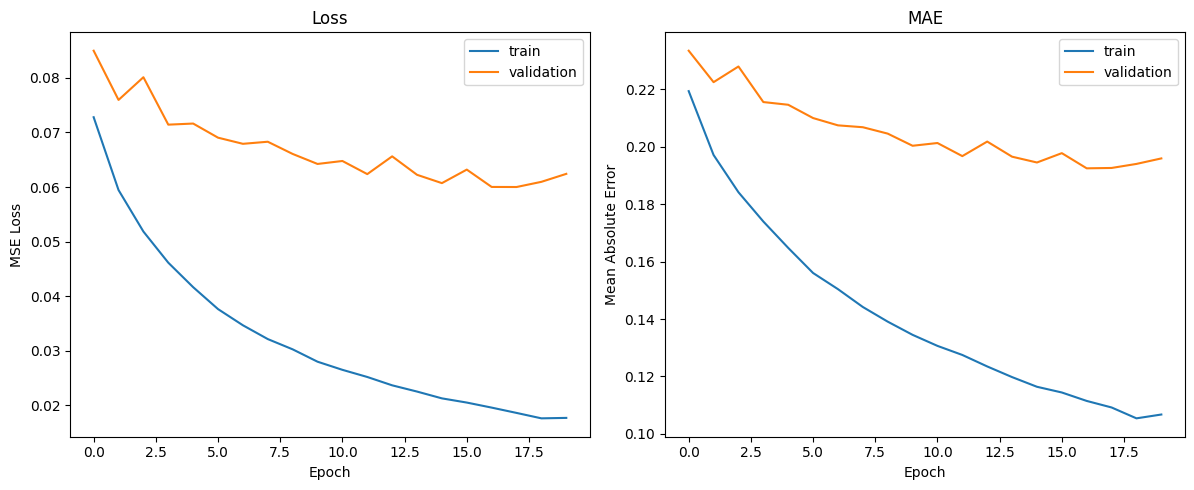

In [24]:
plot_history(history)

In [25]:
def evaluate_model(model: Model, dataset: tf.data.Dataset):
	y_true = np.concatenate([y.numpy() for _, y in dataset], axis=0)
	
	y_pred = model.predict(dataset).flatten()
	
	# Comprueba si la relación entre las predicciones y las etiquetas sigue una línea recta.
	# - 1.0 --> correlación positiva perfecta
	# - 0.0 --> sin correlación
	# - -1.0 --> correlación negativa perfecta
	pearson, _ = pearsonr(y_true, y_pred)
	# Compara el orden de las predicciones y los valores reales.
	spearman, _ = spearmanr(y_true, y_pred)
	mse = np.mean((y_true - y_pred) ** 2)
	mae = np.mean(np.abs(y_true - y_pred))

	print(
		f"Pearson: {pearson:.4f} | "
		f"Spearman: {spearman:.4f} | "
		f"MSE: {mse:.6f} | "
		f"MAE: {mae:.6f}"
	)
	

In [26]:
evaluate_model(model, test_dataset)


22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step
Pearson: 0.6466 | Spearman: 0.6326 | MSE: 0.067014 | MAE: 0.200583


In [37]:
sentences = [
    "El gato duerme en la cama",
    "El perro duerme, pero luego se despierta"
]

sentence_tensor = vectorizer(sentences)
print("Sentence tensor shape:", sentence_tensor.shape)

vecs = head_model(sentence_tensor)
print("Embeddings shape:", vecs.shape)

for i, sentence in enumerate(sentences):
    print(f"\nSentence {i+1}: '{sentence}'")
    print("Sentence tensor:")
    print(sentence_tensor[i])

sim = cosine_similarity(vecs[0].unsqueeze(0), vecs[1].unsqueeze(0))
print("Cosine similarity:", sim.item())

Sentence tensor shape: torch.Size([2, 25])
Embeddings shape: torch.Size([2, 50])

Sentence 1: 'El gato duerme en la cama'
Sentence tensor:
tensor([   5,   79, 4803,    4,    3,  789,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0], device='cuda:0')

Sentence 2: 'El perro duerme, pero luego se despierta'
Sentence tensor:
tensor([   5,   26, 4803,   63, 1133,   14,    1,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0], device='cuda:0')
Cosine similarity: 0.6119951605796814


**Last hidden state + Manhattan similarity (original MaLSTM)**

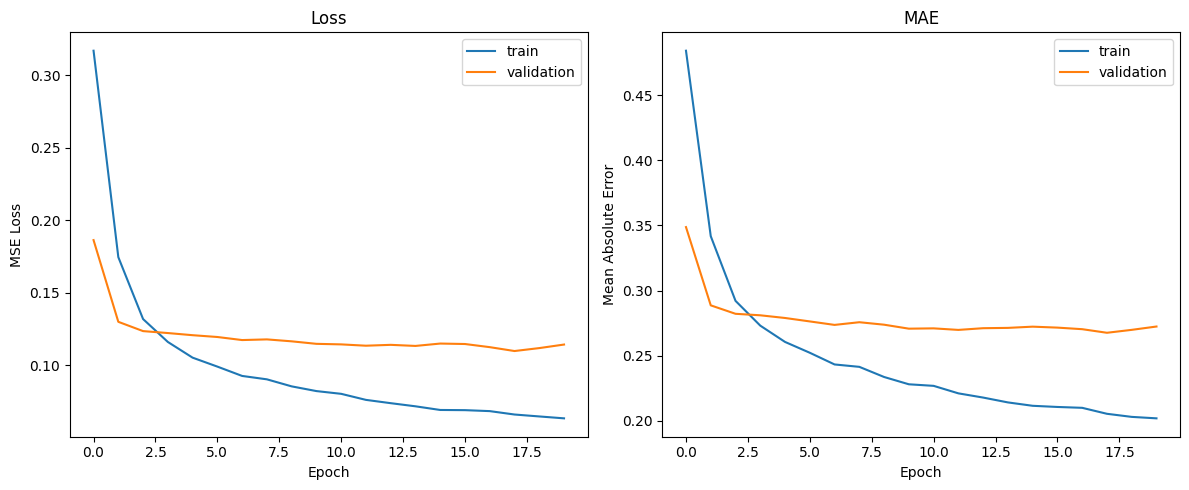

**Last hidden state + Cosine similarity**

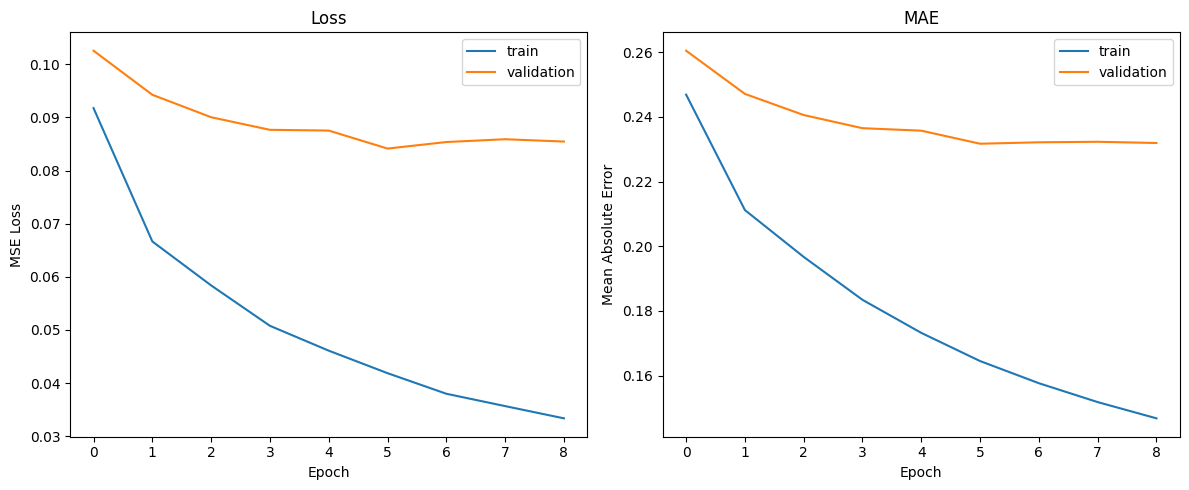

**Mean pooling of all hidden states + Manhattan**

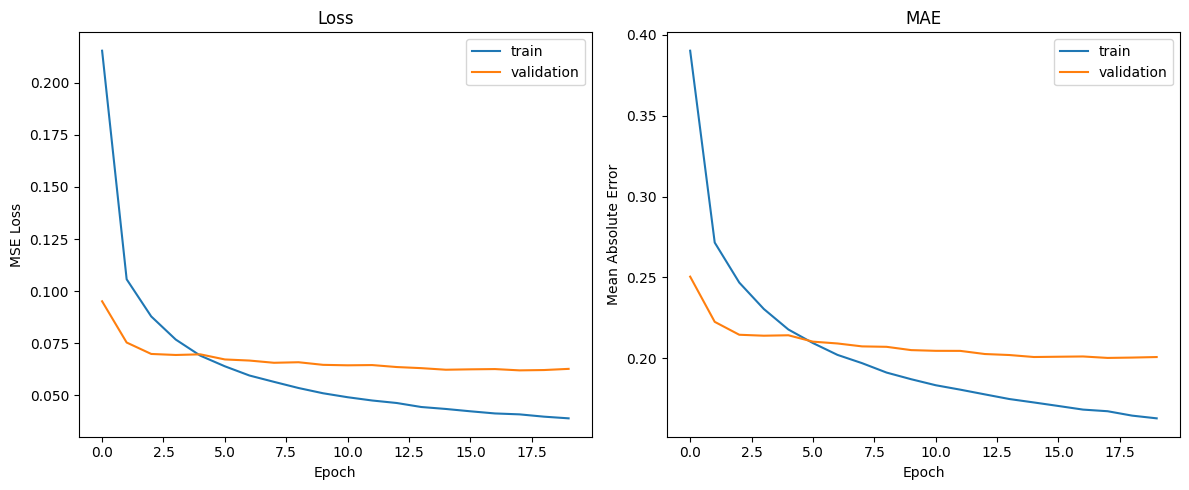

**Mean pooling of all hidden states + Cosine**

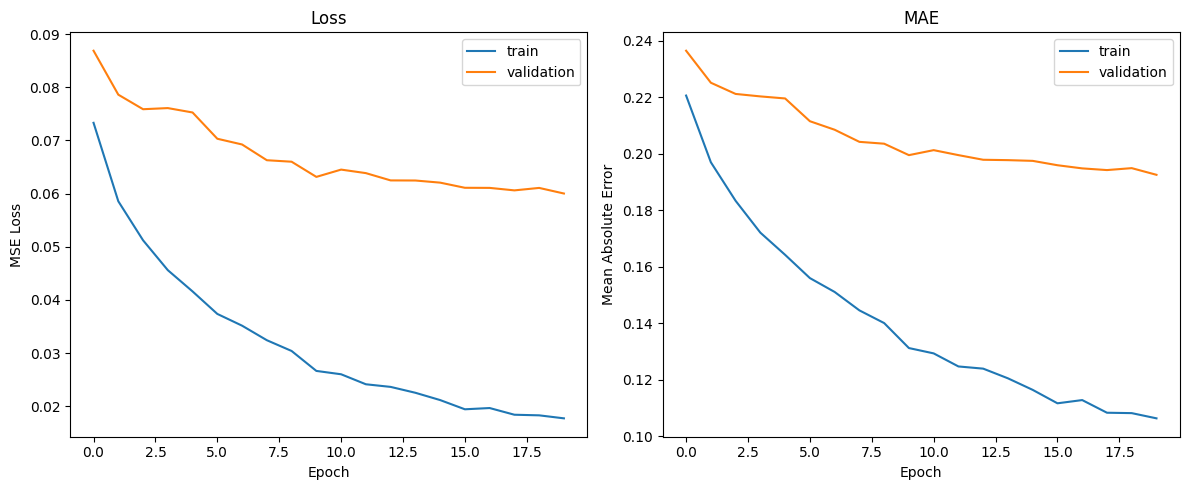


| Configuración | Épocas | Loss (train) | MAE (train) | Loss (val) | MAE (val) | Pearson (test) | Spearman (test) | MSE (test) | MAE (test) |
|---------------|--------|--------------|-------------|----------|---------|---------|----------|-----|------------|
| Last hidden state + Manhattan | 20 | 0.0635 | 0.2018 | 0.1143 | 0.2723 | 0.4069 | 0.4094 | 0.109343 | 0.260309 |
| Last hidden state + Cosine | 10 | 0.0334 | 0.1468 | 0.0855 | 0.2319 | 0.5877 | 0.5710 | 0.076134 | 0.218718 |
| Mean pooling + Manhattan | 20 | 0.0390 | 0.1629 | 0.0627 | 0.2008 | 0.5560 | 0.5417 | 0.066399 | 0.202934 |
| Mean pooling + Cosine | 20 | **0.0177** | **0.1063** | **0.0600** | **0.1925** | **0.6485** | **0.6364** | **0.065854** | **0.199555** |
